# Currency Crash Prediction - Data Exploration

Explore FX rates and interest rate data for 17 economies (2006-2023)

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_fetcher import CurrencyDataFetcher

sns.set_style('darkgrid')
%matplotlib inline

## 1. Fetch Data

In [2]:
fetcher = CurrencyDataFetcher()
fx_rates, interest_rates = fetcher.fetch_all_data('2007-01-01', '2025-12-31')

print(f"FX Rates: {fx_rates.shape}")
print(f"Interest Rates: {interest_rates.shape}")

2026-03-02 17:12:07.142 | INFO     | data_fetcher:fetch_all_data:159 - Fetching data from 2007-01-01 to 2025-12-31
2026-03-02 17:12:07.142 | INFO     | data_fetcher:fetch_fx_rates_yfinance:67 - Fetching EURUSD=X from Yahoo Finance


YF.download() has changed argument auto_adjust default to True


2026-03-02 17:12:08.297 | INFO     | data_fetcher:fetch_fx_rates_yfinance:88 - Successfully fetched 4926 data points for EURUSD=X
2026-03-02 17:12:08.297 | INFO     | data_fetcher:fetch_fx_rates_yfinance:67 - Fetching JPYUSD=X from Yahoo Finance
2026-03-02 17:12:08.856 | INFO     | data_fetcher:fetch_fx_rates_yfinance:88 - Successfully fetched 4926 data points for JPYUSD=X
2026-03-02 17:12:08.856 | INFO     | data_fetcher:fetch_fx_rates_yfinance:67 - Fetching GBPUSD=X from Yahoo Finance
2026-03-02 17:12:09.397 | INFO     | data_fetcher:fetch_fx_rates_yfinance:88 - Successfully fetched 4938 data points for GBPUSD=X
2026-03-02 17:12:09.398 | INFO     | data_fetcher:fetch_fx_rates_yfinance:67 - Fetching CADUSD=X from Yahoo Finance
2026-03-02 17:12:09.977 | INFO     | data_fetcher:fetch_fx_rates_yfinance:88 - Successfully fetched 4941 data points for CADUSD=X
2026-03-02 17:12:09.977 | INFO     | data_fetcher:fetch_fx_rates_yfinance:67 - Fetching AUDUSD=X from Yahoo Finance
2026-03-02 17:12

FX Rates: (228, 17)
Interest Rates: (228, 17)


## 2. Visualize FX Rates

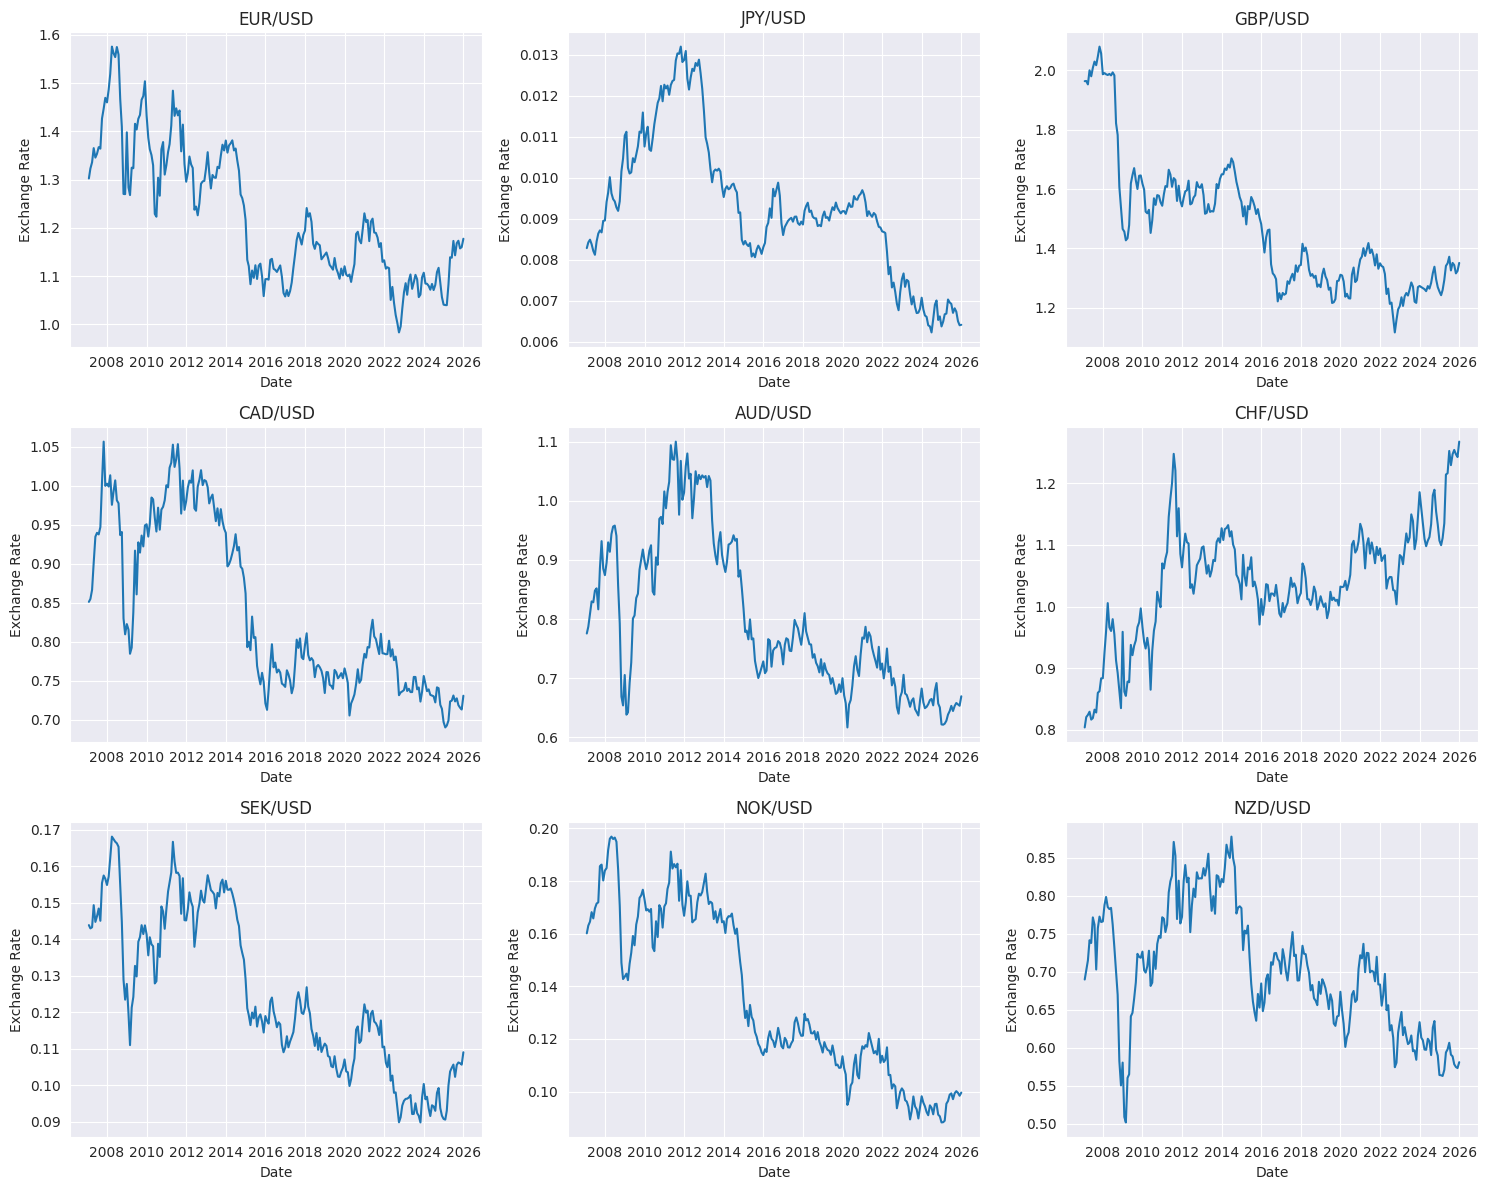

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, currency in enumerate(fx_rates.columns[:9]):
    axes[i].plot(fx_rates.index, fx_rates[currency])
    axes[i].set_title(f'{currency}/USD')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Exchange Rate')

plt.tight_layout()
plt.show()

## 3. Visualize Interest Rates

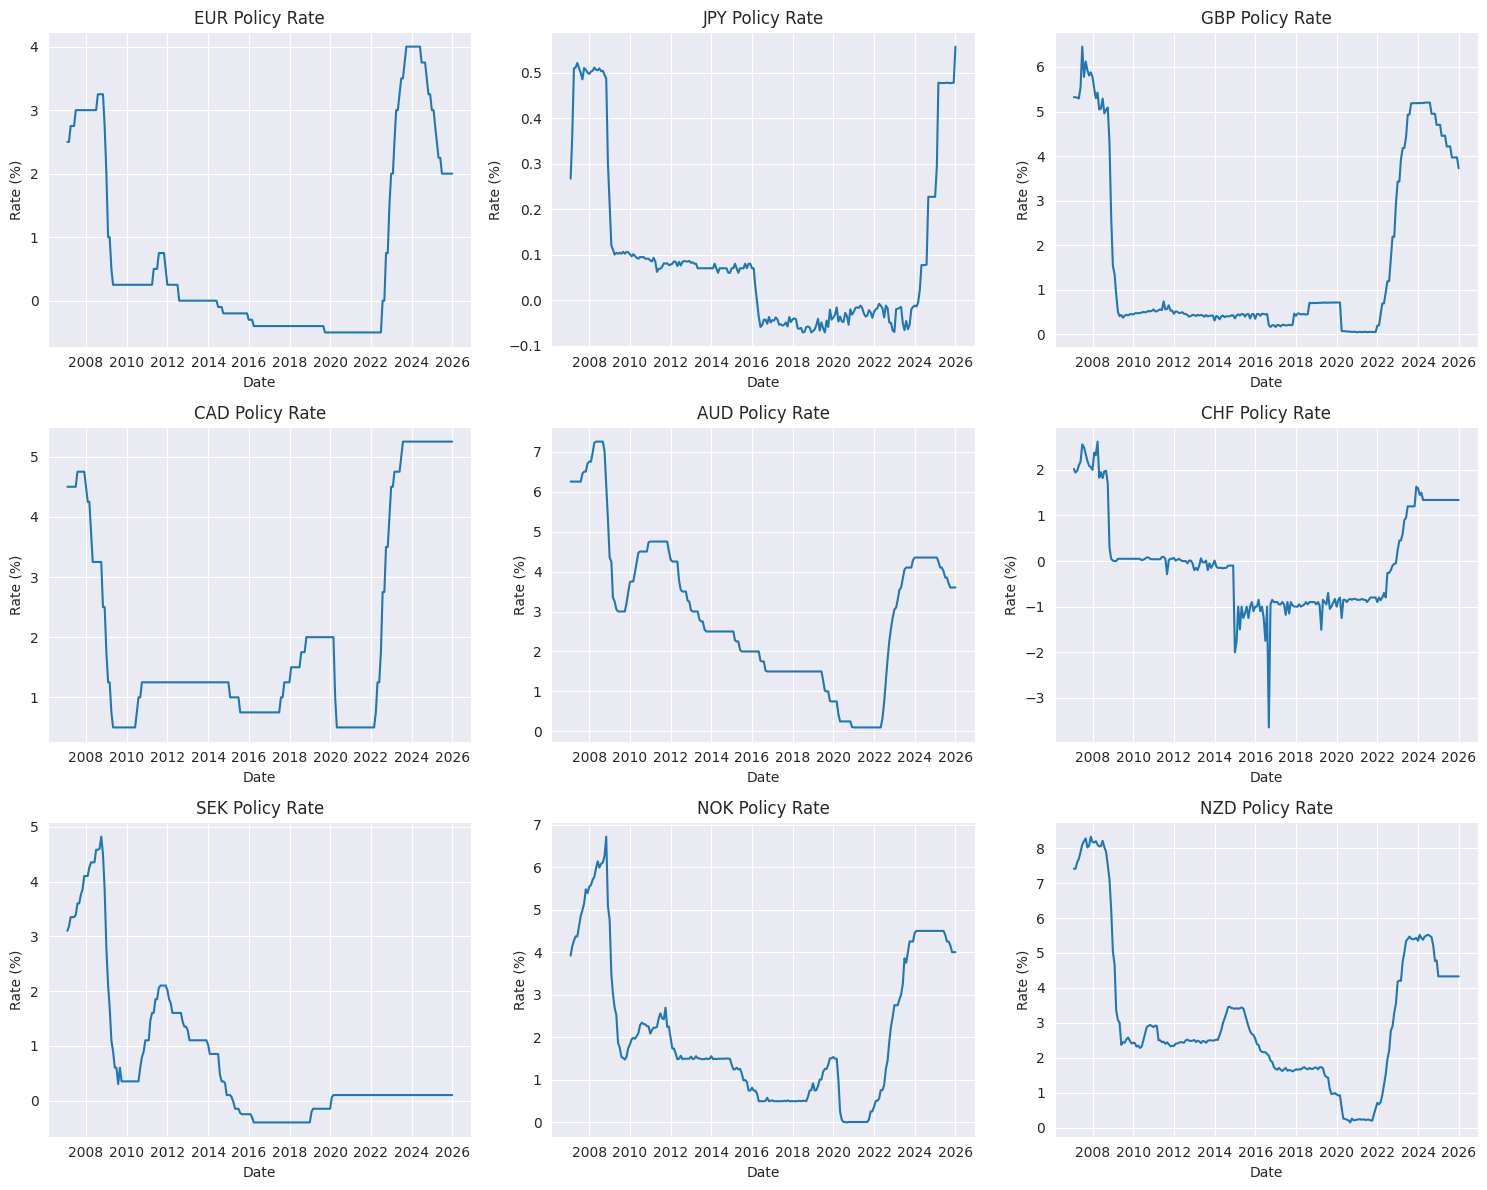

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, currency in enumerate(interest_rates.columns[:9]):
    axes[i].plot(interest_rates.index, interest_rates[currency])
    axes[i].set_title(f'{currency} Policy Rate')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Rate (%)')

plt.tight_layout()
plt.show()

## 4. Calculate Monthly Returns Distribution

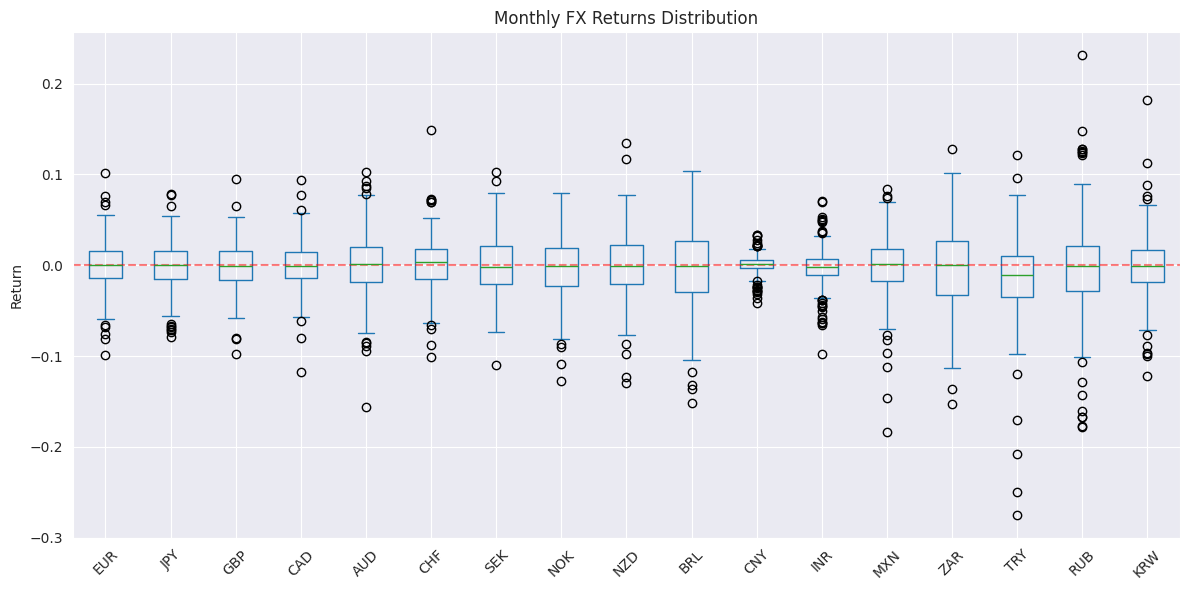

In [5]:
monthly_returns = fx_rates.pct_change()

fig, ax = plt.subplots(figsize=(12, 6))
monthly_returns.plot(kind='box', ax=ax)
ax.set_title('Monthly FX Returns Distribution')
ax.set_ylabel('Return')
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Summary Statistics

In [6]:
print("FX Rates Summary:")
print(fx_rates.describe())

print("\nInterest Rates Summary:")
print(interest_rates.describe())

print("\nMonthly Returns Summary:")
print(monthly_returns.describe())

FX Rates Summary:
              EUR         JPY         GBP         CAD         AUD         CHF  \
count  228.000000  228.000000  228.000000  228.000000  228.000000  228.000000   
mean     1.222702    0.009281    1.468167    0.839022    0.797524    1.043299   
std      0.137766    0.001710    0.218611    0.106314    0.129317    0.091788   
min      0.982956    0.006223    1.116944    0.689988    0.616899    0.803536   
25%      1.108012    0.008340    1.292909    0.747876    0.691860    1.003530   
50%      1.178933    0.009143    1.409263    0.792136    0.761857    1.044753   
75%      1.331638    0.010152    1.598894    0.945270    0.896705    1.101140   
max      1.575796    0.013203    2.079780    1.056301    1.100001    1.267909   

              SEK         NOK         NZD         BRL         CNY         INR  \
count  228.000000  228.000000  228.000000  228.000000  228.000000  228.000000   
mean     0.124509    0.135236    0.700481    0.354587    0.149066    0.016499   
std      

## 6. Correlation Analysis

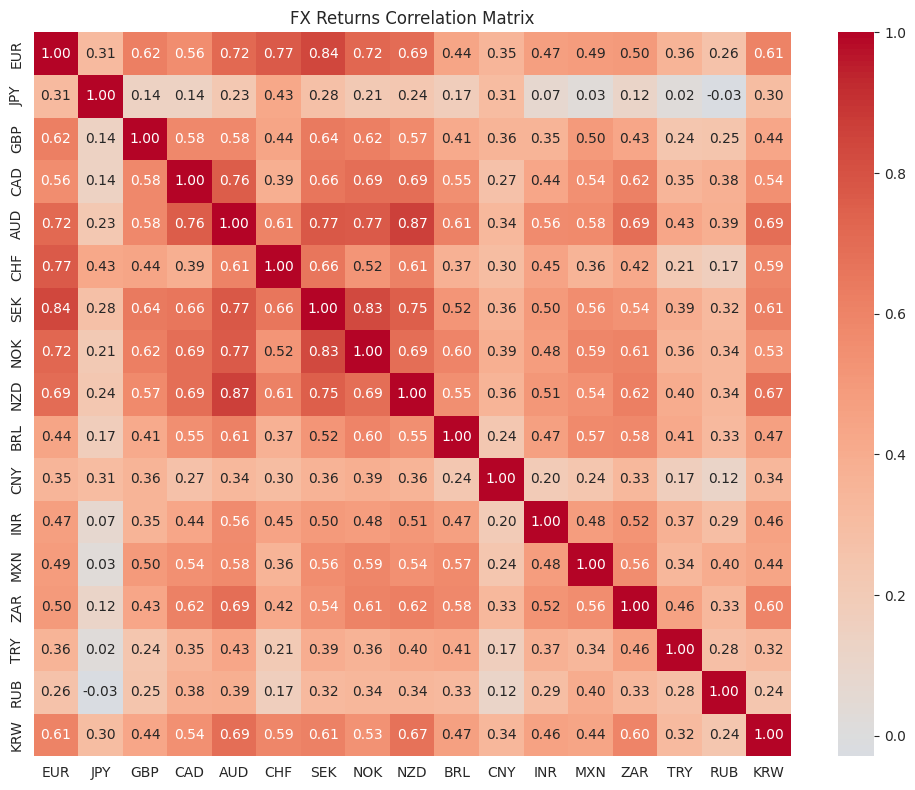

In [7]:
# FX returns correlation
corr = monthly_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('FX Returns Correlation Matrix')
plt.tight_layout()
plt.show()